In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [20]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocess import load_data, preprocess_data
from src.kmeans import train_kmeans, evaluate_kmeans
from src.random_forest_model import train_random_forest, get_feature_importances
from src.neural_network import build_neural_network, train_neural_network, predict_neural_network
from src.evalutation import evaluate_model
from src.visualization import plot_heatmap, plot_feature_importance

In [25]:
import kagglehub
import shutil
import os

# Download latest version
path = kagglehub.dataset_download("jacklizhi/creditcard")
print("Downloaded to:", path)

# Copy all files to the project's data/ directory
data_dir = os.path.abspath('../data')
os.makedirs(data_dir, exist_ok=True)

for file in os.listdir(path):
    src = os.path.join(path, file)
    dst = os.path.join(data_dir, file)
    if os.path.isfile(src):
        shutil.copy2(src, dst)
        print(f"Copied: {file} -> {data_dir}")

print("Done! Files stored in:", data_dir)


Downloaded to: /Users/amaylugun/.cache/kagglehub/datasets/jacklizhi/creditcard/versions/1
Copied: creditcard.csv -> /Volumes/T7/Coding/Projects BIT/DAI/Financial Security/data
Done! Files stored in: /Volumes/T7/Coding/Projects BIT/DAI/Financial Security/data


In [26]:
df = load_data('../data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [27]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

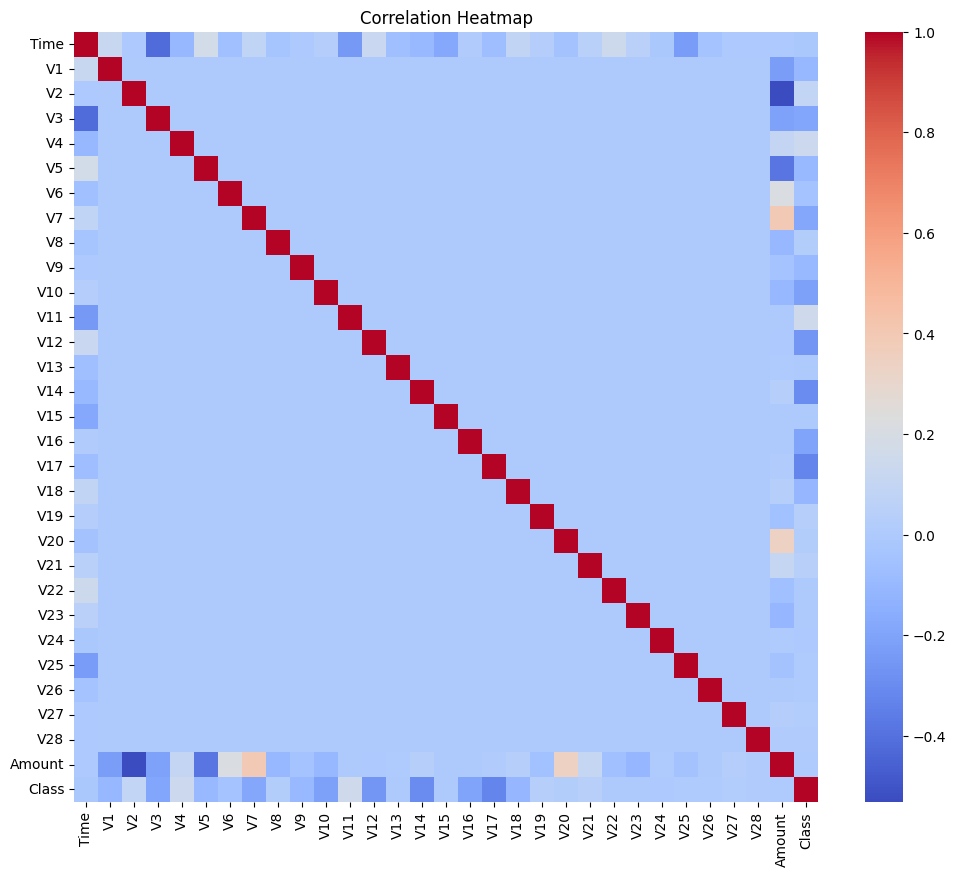

In [6]:
fig = plot_heatmap(df)
plt.show()

Preprocessing of data and balancing data using smote

In [8]:
X_train, X_test, y_train, y_test, scaler = preprocess_data(df, use_smote=True)

Kmeans

In [10]:
kmeans_model, clusters = train_kmeans(X_train)
kmeans_result = evaluate_kmeans(clusters, y_train)
print(kmeans_result)

Cluster       0       1
Actual                 
0        227424  147292
1            27   80159


RandomForest

In [ ]:
from src.random_forest_model import evaluate_random_forest

# Train on the training data
rf_model = train_random_forest(X_train, y_train)

# Predict on the test data 
y_pred_rf = rf_model.predict(X_test)

# Evaluate 
rf_recall, rf_cm = evaluate_random_forest(y_test, y_pred_rf)

print("Recall (RF) : ", rf_recall)
print("Confusion Matrix: \n", rf_cm)


Recall (RF) :  0.826530612244898
Confusion Matrix: 
 [[56852    12]
 [   17    81]]


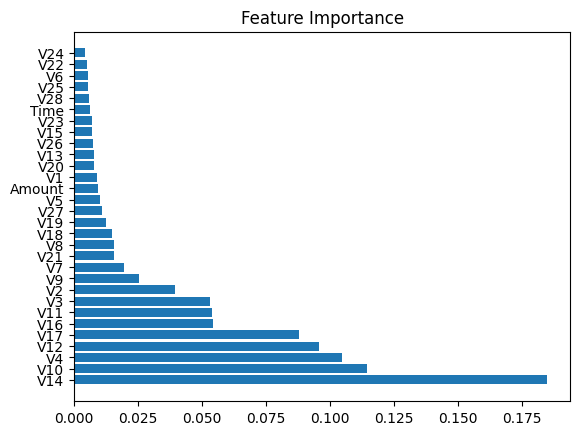

In [15]:
importances = get_feature_importances(rf_model)

fig = plot_feature_importance(importances, df.drop('Class', axis=1).columns)
plt.show()

Neural Network

In [16]:
from src.neural_network import evaluate_neural_network
nn_model = build_neural_network(X_train.shape[1])
nn_model = train_neural_network(nn_model, X_train, y_train, epochs=10)

y_pred_nn = (nn_model.predict(X_test) > 0.5).astype(int)

nn_recall, nn_cm = evaluate_neural_network(y_test, y_pred_nn)

print("Recall (NN) :", nn_recall)
print("Confusion Matrix :\n", nn_cm)

Epoch 1/10


/Volumes/T7/Coding/Projects BIT/DAI/Financial Security/myenv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11373/11373 ━━━━━━━━━━━━━━━━━━━━ 11s 818us/step - Recall: 0.9666 - loss: 0.0678 - val_Recall: 0.9985 - val_loss: 0.0227
Epoch 2/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 9s 824us/step - Recall: 0.9910 - loss: 0.0304 - val_Recall: 0.9998 - val_loss: 0.0070
Epoch 3/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 10s 842us/step - Recall: 0.9933 - loss: 0.0247 - val_Recall: 0.9997 - val_loss: 0.0115
Epoch 4/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 8s 733us/step - Recall: 0.9950 - loss: 0.0212 - val_Recall: 0.9999 - val_loss: 0.0067
Epoch 5/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 9s 749us/step - Recall: 0.9953 - loss: 0.0188 - val_Recall: 0.9997 - val_loss: 0.0112
Epoch 6/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 9s 754us/step - Recall: 0.9962 - loss: 0.0167 - val_Recall: 1.0000 - val_loss: 0.0042
Epoch 7/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 8s 733us/step - Recall: 0.9961 - loss: 0.0162 - val_Recall: 1.0000 - val_loss: 0.0062
Epoch 8/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 8s 738us/step - Recall: 0.9965 - loss: 0.0152 - val_Rec

In [17]:
import joblib

os.makedirs("../models", exist_ok=True)
joblib.dump(rf_model, "../models/rf_model.pkl")
nn_model.save("../models/nn_model.keras")

In [28]:
import joblib
rf_model = joblib.load("../models/rf_model.pkl")
from tensorflow.keras.models import load_model
nn_model = nn_model = load_model("../models/nn_model.keras")

y_pred = rf_model.predict(X_test)
rf_recall, rf_cm = evaluate_random_forest(y_test, y_pred_rf)

print("Recall (RF) : ",rf_recall)
print("Confusion Matrix: \n",rf_cm)

#----------------------------------------
y_pred_nn = (nn_model.predict(X_test) > 0.5).astype(int)

nn_recall, nn_cm = evaluate_neural_network(y_test, y_pred_nn)

print("Recall (NN) :", nn_recall)
print("Confusion Matrix :\n", nn_cm)

Recall (RF) :  0.826530612244898
Confusion Matrix: 
 [[56852    12]
 [   17    81]]
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 279us/step
Recall (NN) : 0.8673469387755102
Confusion Matrix :
 [[56753   111]
 [   13    85]]


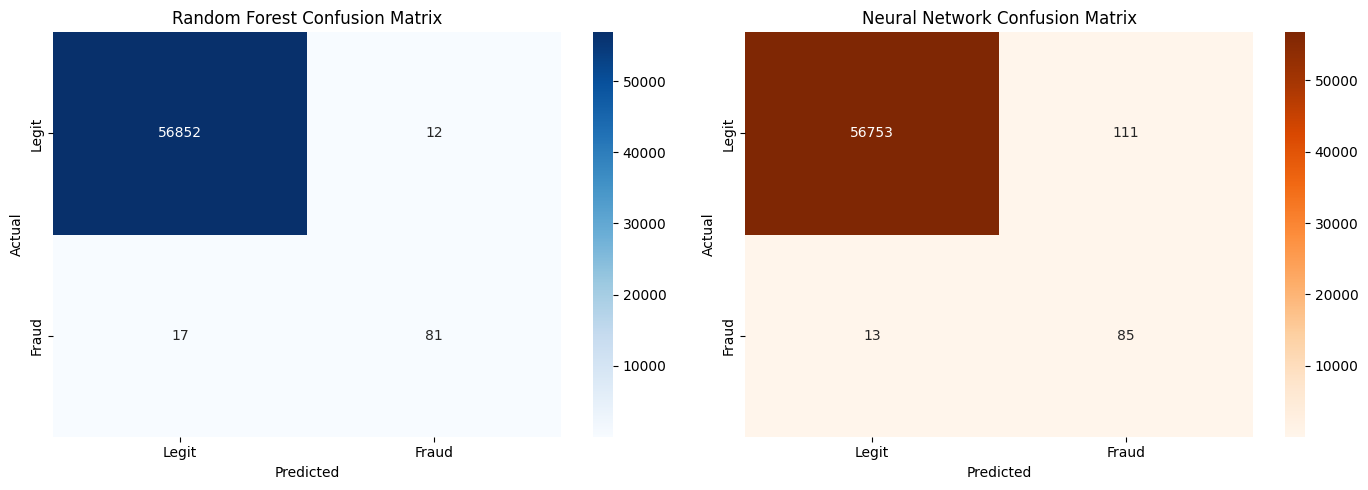

In [29]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Plot Random Forest Confusion Matrix
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
ax1.set_title('Random Forest Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
# Plot Neural Network Confusion Matrix
sns.heatmap(nn_cm, annot=True, fmt='d', cmap='Oranges', ax=ax2,
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
ax2.set_title('Neural Network Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
plt.tight_layout()
plt.show()